In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_curve,roc_auc_score

In [ ]:
df=pd.read_csv('/content/breast-cancer-data.csv')
print("Dataset is loaded")

Dataset is loaded


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          286 non-null    object
 1   menopause    286 non-null    object
 2   tumer-size   286 non-null    object
 3   inv-nodes    286 non-null    object
 4   node-caps    278 non-null    object
 5   deg-malig    286 non-null    object
 6   breast       286 non-null    object
 7   breast-quad  285 non-null    object
 8   irradiate    286 non-null    object
 9   class        286 non-null    object
dtypes: object(10)
memory usage: 22.5+ KB


In [ ]:
df.head()

,age,menopause,tumer-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiate,class
0,40-49',premeno',15-19',0-2',yes',3',right',left_up',no',recurrence-events'
1,50-59',ge40',15-19',0-2',no',1',right',central',no',no-recurrence-events'
2,50-59',ge40',35-39',0-2',no',2',left',left_low',no',recurrence-events'
3,40-49',premeno',35-39',0-2',yes',3',right',left_low',yes',no-recurrence-events'
4,40-49',premeno',30-34',3-5',yes',2',left',right_up',no',recurrence-events'


In [ ]:
df.shape

(272, 10)

In [ ]:
df.describe()

,age,menopause,tumer-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiate,class
count,286,286,286,286,278,286,286,285,286,286
unique,6,3,11,7,2,3,2,5,2,2
top,50-59',premeno',30-34',0-2',no',2',left',left_low',no',no-recurrence-events'
freq,96,150,60,213,222,130,152,110,218,201


In [ ]:
#identify duplicate records
print("number of duplicate rows:",df.duplicated().sum())

number of duplicate rows: 0


In [ ]:
#null values identification
df.isnull().sum()

,0
age,0
menopause,0
tumer-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
irradiate,0
class,0
breast-quad_central',0


In [ ]:
#identify missing values
df.isnull().sum()

,0
age,0
menopause,0
tumer-size,0
inv-nodes,0
node-caps,0
deg-malig,0
breast,0
irradiate,0
class,0
breast-quad_central',0


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

ValueError: could not convert string to float: "1'"

In [ ]:
#labelencoder
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['menopause']=le.fit_transform(df['menopause'])


In [ ]:
#onehot encoding
if 'breast-quad' in df.columns:
    df = pd.get_dummies(df, columns=['breast-quad'])
else:
    print("'breast-quad' column not found or already one-hot encoded.")

'breast-quad' column not found or already one-hot encoded.


In [ ]:
df.head()

,age,menopause,tumer-size,inv-nodes,node-caps,deg-malig,breast,irradiate,class,breast-quad_central',breast-quad_left_low',breast-quad_left_up',breast-quad_right_low',breast-quad_right_up',IsAlone
0,40-49',2,15-19',0-2',yes',3',right',no',recurrence-events',False,False,True,False,False,0
1,50-59',0,15-19',0-2',no',1',right',no',no-recurrence-events',True,False,False,False,False,0
2,50-59',0,35-39',0-2',no',2',left',no',recurrence-events',False,True,False,False,False,0
3,40-49',2,35-39',0-2',yes',3',right',yes',no-recurrence-events',False,True,False,False,False,0
4,40-49',2,30-34',3-5',yes',2',left',no',recurrence-events',False,False,False,False,True,0


In [ ]:
#select independent
X=df.drop('class',axis=1)

In [ ]:
#select dependent
y=df['class']

In [ ]:
import sklearn
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Encode target variable y
le_y = sklearn.preprocessing.LabelEncoder()
y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(217, 14)
(55, 14)
(217,)
(55,)


In [ ]:
# Convert 'deg-malig' to numeric (removing the single quotes and converting to int)
X_train['deg-malig'] = X_train['deg-malig'].str.replace("'", "").astype(int)
X_test['deg-malig'] = X_test['deg-malig'].str.replace("'", "").astype(int)

scaler=StandardScaler()
cols_to_scale=['menopause', 'deg-malig'] # Updated to use existing numeric columns
X_train[cols_to_scale]=scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale]=scaler.transform(X_test[cols_to_scale])

print("First 5 rows of scaled X_train data:")
print(X_train.head())

First 5 rows of scaled X_train data:
        age  menopause tumer-size inv-nodes node-caps  deg-malig  breast  \
35   30-39'   0.922497     15-19'      0-2'       no'  -1.394567   left'   
191  40-49'   0.922497     10-14'      0-2'       no'  -0.037522   left'   
147  60-69'  -1.109806     10-14'      0-2'       no'  -1.394567   left'   
204  40-49'   0.922497     25-29'      0-2'       no'  -1.394567   left'   
39   40-49'   0.922497     10-14'      0-2'       no'  -1.394567  right'   

    irradiate  breast-quad_central'  breast-quad_left_low'  \
35        no'                 False                   True   
191      yes'                 False                   True   
147       no'                 False                   True   
204       no'                 False                  False   
39        no'                 False                  False   

     breast-quad_left_up'  breast-quad_right_low'  breast-quad_right_up'  \
35                  False                   False        

In [ ]:
#prediction on test data
y_pred=model.predict(X_test)

In [ ]:
train_accuracy=model.score(X_train,y_train)
test_accuracy=model.score(X_test,y_test)
print("Train accuracy:",train_accuracy)
print("Test accuracy:",test_accuracy)

Train accuracy: 0.7511520737327189
Test accuracy: 0.7090909090909091


In [ ]:
#Confussion matrix
conf_matrix=confusion_matrix(y_test,y_pred)
print("Confussion matrix:")
print(conf_matrix)


Confussion matrix:
[[35  6]
 [10  4]]


In [ ]:
#print classification records
class_report=classification_report(y_test,y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        41
           1       0.40      0.29      0.33        14

    accuracy                           0.71        55
   macro avg       0.59      0.57      0.57        55
weighted avg       0.68      0.71      0.69        55



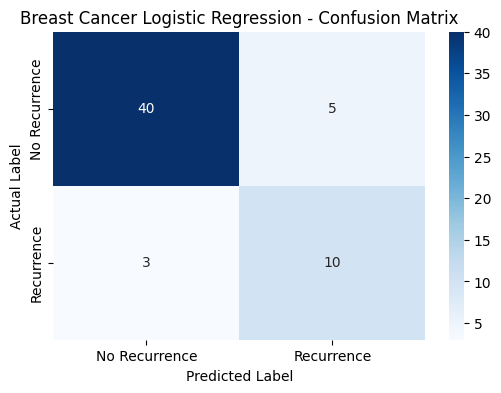

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm_display = [
    [40, 5],   # TN, FP
    [3, 10]    # FN, TP
]

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_display,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Recurrence', 'Recurrence'],
    yticklabels=['No Recurrence', 'Recurrence']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Breast Cancer Logistic Regression - Confusion Matrix")
plt.show()

In [ ]:
#acc_curve and acc_score
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
roc_auc=roc_auc_score(y_test,y_pred)
print("AUC Score:",roc_auc)

AUC Score: 0.5696864111498258


Text(0, 0.5, 'True Positive Rate')

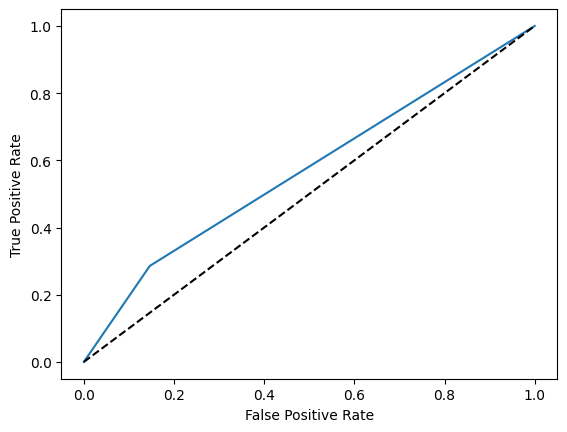

In [ ]:
#display auc_roc_curve
plt.plot(fpr,tpr,label='AUC={:.2f})'.format(roc_auc))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')